# Experiment A Analysis

This notebook reproduces the main statistical analysis for Experiment A.

# Statistical Summary

Primary hypothesis testing methods:

Experiment A:
- Binomial test
- Confidence interval
- Cohen’s h

Experiment B:
- Welch t-test
- Chi-square test
- Cramér’s V
- Cohen’s d

## Files used
- `experiment_a_data_participant_summary.csv`
- `experiment_a_data_scenario.csv`

## Main analyses
1. Binomial test on final participant preference
2. 95% confidence interval for aligned preference proportion
3. Cohen's h for practical significance
4. Paired t-test on mean aligned vs generic scores
5. Cohen's d for paired mean difference
6. Persona-level summary
7. Scenario-level summary
8. Visualization export


In [5]:
import pandas as pd
import numpy as np
import math
from scipy import stats
import matplotlib.pyplot as plt
from pathlib import Path

pd.options.display.float_format = '{:.4f}'.format

base = Path(".")

In [6]:
part = pd.read_csv(base / "../data/experiment_a_data_participant_summary.csv", sep=";", decimal=",", encoding="utf-8-sig")
part.head() 

,Participant_ID,Persona,Form_Version,Aligned_Count,Generic_Count,Total_Scenarios,Aligned_Rate,Final_Preference,Mean_Aligned_Score,Mean_Generic_Score,Difference_Score,Overall_Preference,Preferred_Aligned
0,P001,STJ,A,6,0,6,1.0000,Aligned,4.5833,3.0833,1.5000,Structured/personalized responses,1
1,P002,STJ,A,0,6,6,0.0000,Generic,3.1250,2.5417,0.5833,Structured/personalized responses,0
2,P003,STJ,A,6,0,6,1.0000,Aligned,5.0000,3.0000,2.0000,No preference,1
3,P004,STJ,A,5,1,6,0.8333,Aligned,4.4167,2.8750,1.5417,Generic responses,1
4,P005,STJ,A,5,1,6,0.8333,Aligned,4.4167,3.8750,0.5417,Generic responses,1


In [7]:
scen = pd.read_csv(base / "../data/experiment_a_data_scenario.csv", sep=";", decimal=",", encoding="utf-8-sig")
scen.head()

,Participant_ID,Scenario_ID,Persona,Form_Version,Aligned_Response,Clarity_A,Clarity_B,Satisfaction_A,Satisfaction_B,Trust_A,...,Clarity_Aligned,Clarity_Generic,Satisfaction_Aligned,Satisfaction_Generic,Trust_Aligned,Trust_Generic,Reuse_Aligned,Reuse_Generic,Mean_Aligned,Mean_Generic
0,P001,S1_Student_Exchange,STJ,A,A,5,4,5,3,4,...,5,4,5,3,4,3,5,4,4.7500,3.5000
1,P001,S2_Tuition_Payment,STJ,A,A,5,4,4,2,4,...,5,4,4,2,4,3,5,3,4.5000,3.0000
2,P001,S3_Wi-Fi_Access,STJ,A,A,5,2,4,2,4,...,5,2,4,2,4,3,5,3,4.5000,2.5000
3,P001,S4_Suspicious_Email,STJ,A,A,5,2,5,3,5,...,5,2,5,3,5,3,5,4,5.0000,3.0000
4,P001,S5_Attendance_Policy,STJ,A,A,5,3,4,3,4,...,5,3,4,3,4,4,4,3,4.2500,3.2500


In [8]:
# Core Experiment A calculations
n = len(part)
aligned_n = int((part["Final_Preference"] == "Aligned").sum())
generic_n = int((part["Final_Preference"] == "Generic").sum())
p_hat = aligned_n / n

binom_res = stats.binomtest(aligned_n, n=n, p=0.5, alternative="greater")
ci = binom_res.proportion_ci(confidence_level=0.95, method="wilson")
cohens_h = 2 * (math.asin(math.sqrt(p_hat)) - math.asin(math.sqrt(0.5)))

mean_aligned = part["Mean_Aligned_Score"].mean()
mean_generic = part["Mean_Generic_Score"].mean()
mean_diff = part["Difference_Score"].mean()

sd_diff = part["Difference_Score"].std(ddof=1)
se_diff = sd_diff / math.sqrt(n)

t_res = stats.ttest_rel(part["Mean_Aligned_Score"], part["Mean_Generic_Score"])
t_crit = stats.t.ppf(0.975, df=n-1)

wilcoxon_res = stats.wilcoxon(part["Mean_Aligned_Score"], part["Mean_Generic_Score"], alternative="greater")

ci_diff_low = mean_diff - t_crit * se_diff
ci_diff_high = mean_diff + t_crit * se_diff

cohens_d_paired = mean_diff / sd_diff

summary = pd.DataFrame({
    "Metric": [
        "Participants",
        "Aligned preference count",
        "Generic preference count",
        "Aligned preference proportion",
        "Binomial test p-value",
        "95% CI lower",
        "95% CI upper",
        "Mean aligned score",
        "Mean generic score",
        "Mean difference",
        "Paired t statistic",
        "Paired t-test p-value",
        "Wilcoxon statistic",
        "Wilcoxon p-value",
        "95% CI diff lower",
        "95% CI diff upper",
        "Cohen's h",
        "Cohen's d (paired)"
    ],
    "Value": [
        n,
        aligned_n,
        generic_n,
        p_hat,
        binom_res.pvalue,
        ci.low,
        ci.high,
        mean_aligned,
        mean_generic,
        mean_diff,
        t_res.statistic,
        t_res.pvalue,
        wilcoxon_res.statistic,
        wilcoxon_res.pvalue,
        ci_diff_low,
        ci_diff_high,
        cohens_h,
        cohens_d_paired
    ]
})

summary


,Metric,Value
0,Participants,57.0000
1,Aligned preference count,42.0000
2,Generic preference count,15.0000
3,Aligned preference proportion,0.7368
4,Binomial test p-value,0.0002
5,95% CI lower,0.6318
6,95% CI upper,1.0000
7,Mean aligned score,4.2939
8,Mean generic score,3.3655
9,Mean difference,0.9284


In [9]:
# Persona-level summary
persona_summary = (
    part.groupby("Persona", dropna=False)
    .agg(
        n=("Participant_ID", "count"),
        aligned_count=("Preferred_Aligned", "sum"),
        mean_aligned=("Mean_Aligned_Score", "mean"),
        mean_generic=("Mean_Generic_Score", "mean"),
        mean_difference=("Difference_Score", "mean"),
    )
    .reset_index()
)
persona_summary["aligned_rate"] = persona_summary["aligned_count"] / persona_summary["n"]
persona_summary


,Persona,n,aligned_count,mean_aligned,mean_generic,mean_difference,aligned_rate
0,NFJ,12,8,3.7153,3.1458,0.5694,0.6667
1,NTP,12,9,4.5868,3.6632,0.9236,0.7500
2,SFP,11,8,4.1477,3.2424,0.9053,0.7273
3,STJ,22,17,4.5227,3.3845,1.1383,0.7727


In [10]:
# Scenario-level summary
scenario_summary = (
    scen.groupby("Scenario_ID", dropna=False)
    .agg(
        n=("Participant_ID", "count"),
        mean_aligned=("Mean_Aligned", "mean"),
        mean_generic=("Mean_Generic", "mean"),
    )
    .reset_index()
)
scenario_summary["mean_difference"] = scenario_summary["mean_aligned"] - scenario_summary["mean_generic"]
scenario_summary


,Scenario_ID,n,mean_aligned,mean_generic,mean_difference
0,S1_Student_Exchange,57,4.4211,2.9649,1.4561
1,S2_Tuition_Payment,57,4.3114,3.2632,1.0482
2,S3_Wi-Fi_Access,57,4.3860,3.2456,1.1404
3,S4_Suspicious_Email,57,4.3070,3.6535,0.6535
4,S5_Attendance_Policy,57,4.2281,3.3333,0.8947
5,S6_Elective_Courses,57,4.1053,3.6711,0.4342


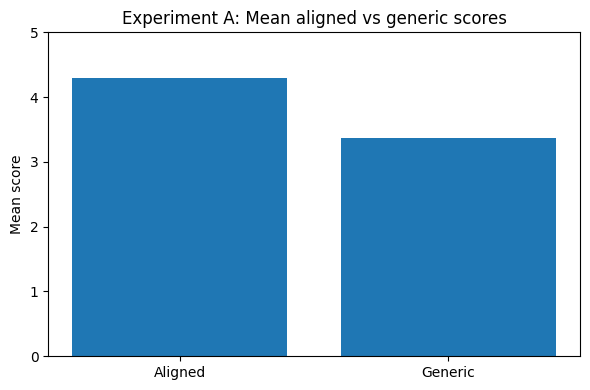

In [11]:
# Visualization 1: Mean aligned vs generic scores
plt.figure(figsize=(6, 4))
plt.bar(["Aligned", "Generic"], [mean_aligned, mean_generic])
plt.ylabel("Mean score")
plt.title("Experiment A: Mean aligned vs generic scores")
plt.ylim(0, 5)
plt.tight_layout()
plt.show()


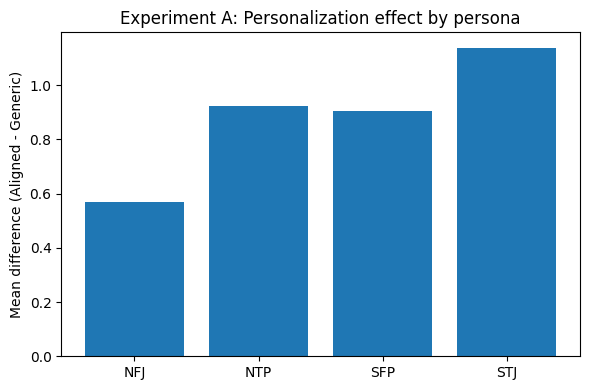

In [12]:
# Visualization 2: Persona-level effect
plt.figure(figsize=(6, 4))
plt.bar(persona_summary["Persona"], persona_summary["mean_difference"])
plt.ylabel("Mean difference (Aligned - Generic)")
plt.title("Experiment A: Personalization effect by persona")
plt.tight_layout()

plt.show()


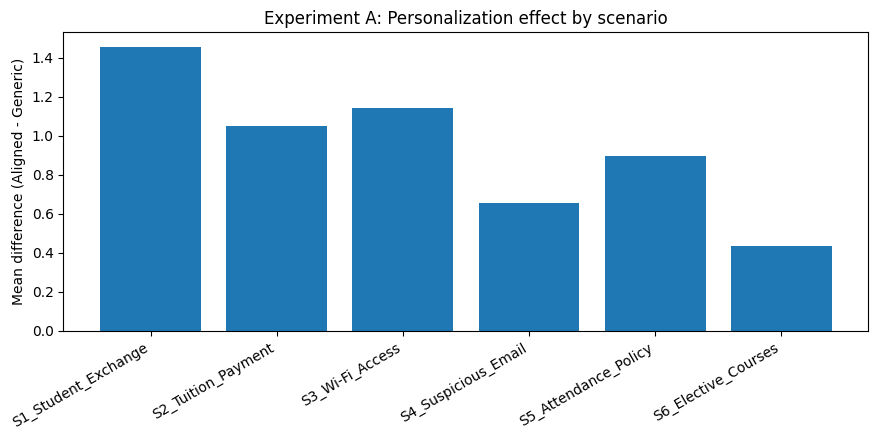

In [13]:
# Visualization 3: Scenario-level effect
plt.figure(figsize=(9, 4.5))
plt.bar(scenario_summary["Scenario_ID"], scenario_summary["mean_difference"])
plt.ylabel("Mean difference (Aligned - Generic)")
plt.title("Experiment A: Personalization effect by scenario")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()

plt.show()


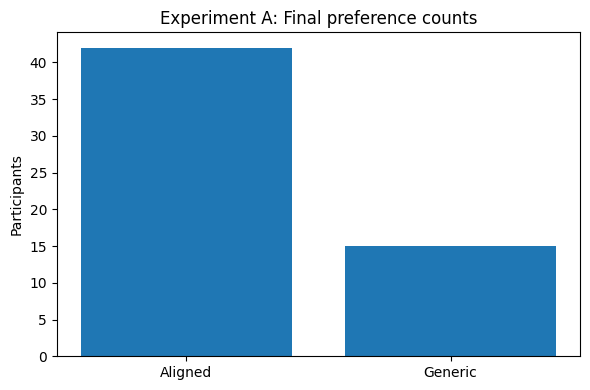

In [14]:
# Visualization 4: Final preference counts
plt.figure(figsize=(6, 4))
plt.bar(["Aligned", "Generic"], [aligned_n, generic_n])
plt.ylabel("Participants")
plt.title("Experiment A: Final preference counts")
plt.tight_layout()

plt.show()


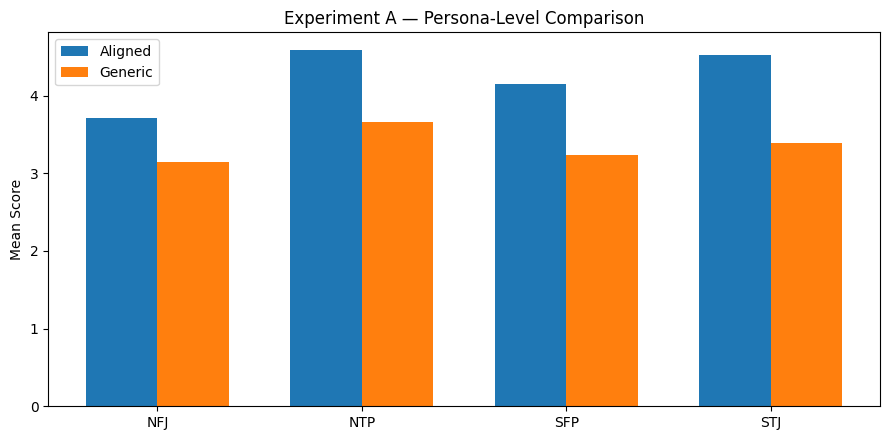

In [15]:
# Visualization 5: Persona-level comparison
x = np.arange(len(persona_summary["Persona"]))
width = 0.35

plt.figure(figsize=(9, 4.5))
plt.bar(x - width/2, persona_summary["mean_aligned"], width)
plt.bar(x + width/2, persona_summary["mean_generic"], width)
plt.xticks(x, persona_summary["Persona"])
plt.ylabel("Mean Score")
plt.title("Experiment A — Persona-Level Comparison")
plt.legend(["Aligned", "Generic"])
plt.tight_layout()

plt.show()

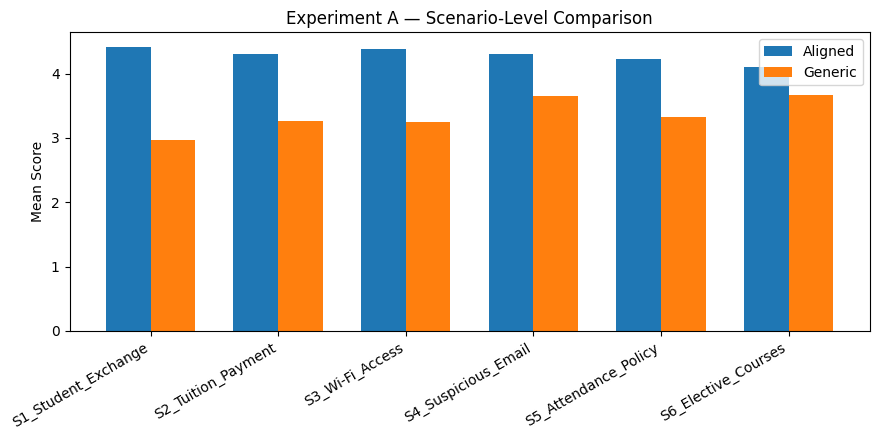

In [16]:
# Visualization 6: Scenario-level comparison
x2 = np.arange(len(scenario_summary.index))

plt.figure(figsize=(9, 4.5))
plt.bar(x2 - width/2, scenario_summary["mean_aligned"], width)
plt.bar(x2 + width/2, scenario_summary["mean_generic"], width)
plt.xticks(x2, scenario_summary["Scenario_ID"], rotation=30, ha="right")
plt.ylabel("Mean Score")
plt.title("Experiment A — Scenario-Level Comparison")
plt.legend(["Aligned", "Generic"])
plt.tight_layout()

plt.show()